In [ ]:
%pip install gym
%pip install numpy
%pip install torch
%pip install optuna
%pip install plotly
%pip install nbformat

def reload_module(m):
    import importlib
    importlib.reload(m)

import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import uts
from consts import *
import optuna
import optuna.visualization as vis
import consts
from te import TradingEnv

# avoid caching
reload_module(uts) 
reload_module(consts) 

utils = uts.Utilities(is_test=consts.IS_TEST, test_num=consts.TEST_NUM)
etf_dfs = utils.get_dataframes('data/ETFs')
stock_dfs = utils.get_dataframes('data/Stocks') 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


[I 2025-05-25 22:50:25,625] A new study created in memory with name: no-name-31959fea-0585-4b84-8ec5-fca4709f80f2
[I 2025-05-25 22:50:28,540] Trial 0 finished with value: 0.0 and parameters: {'gamma': 0.954914509596223, 'clip': 0.2669191550629453, 'lr': 5.284586149811636e-05, 'hidden_dim': 45, 'n_hidden_layers': 2}. Best is trial 0 with value: 0.0.
[I 2025-05-25 22:50:31,009] Trial 1 finished with value: 0.0 and parameters: {'gamma': 0.9560171869628191, 'clip': 0.2582310023742495, 'lr': 0.0005012848653184391, 'hidden_dim': 66, 'n_hidden_layers': 1}. Best is trial 0 with value: 0.0.
[I 2025-05-25 22:50:33,396] Trial 2 finished with value: 3.8805107275644936e-11 and parameters: {'gamma': 0.9646925234702635, 'clip': 0.22541539473299227, 'lr': 9.162489449676031e-05, 'hidden_dim': 67, 'n_hidden_layers': 1}. Best is trial 2 with value: 3.8805107275644936e-11.
[I 2025-05-25 22:50:35,905] Trial 3 finished with value: 0.0 and parameters: {'gamma': 0.8583151605762475, 'clip': 0.2627233622105068,

Error during plotting
Best PPO params: {'gamma': 0.9646925234702635, 'clip': 0.22541539473299227, 'lr': 9.162489449676031e-05, 'hidden_dim': 67, 'n_hidden_layers': 1}


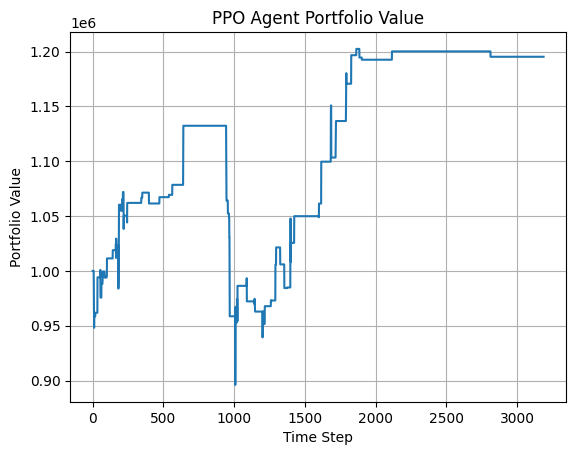

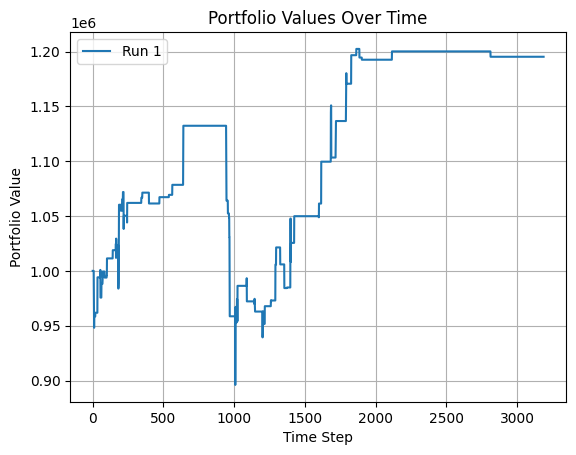

[I 2025-05-25 22:50:52,144] A new study created in memory with name: no-name-7da6c267-31e2-4abd-8094-07ef227dab55
[I 2025-05-25 22:50:54,481] Trial 0 finished with value: 0.0 and parameters: {'gamma': 0.9973072437805832, 'clip': 0.2118129477406731, 'lr': 2.224187618914228e-05, 'hidden_dim': 62, 'n_hidden_layers': 1}. Best is trial 0 with value: 0.0.
[I 2025-05-25 22:50:56,925] Trial 1 finished with value: 0.0 and parameters: {'gamma': 0.8902020788156807, 'clip': 0.14313359550817004, 'lr': 5.9588631839654395e-05, 'hidden_dim': 94, 'n_hidden_layers': 2}. Best is trial 0 with value: 0.0.
[I 2025-05-25 22:50:59,401] Trial 2 finished with value: -7.761021455128987e-11 and parameters: {'gamma': 0.9533793596833848, 'clip': 0.12074403206800864, 'lr': 1.2053306865175817e-05, 'hidden_dim': 96, 'n_hidden_layers': 2}. Best is trial 0 with value: 0.0.
[I 2025-05-25 22:51:01,954] Trial 3 finished with value: 0.0 and parameters: {'gamma': 0.9196355055526648, 'clip': 0.22072965666755995, 'lr': 0.00017

Best PPO params: {'gamma': 0.8711228715353458, 'clip': 0.18676241433577215, 'lr': 0.0006868358403586875, 'hidden_dim': 89, 'n_hidden_layers': 2}


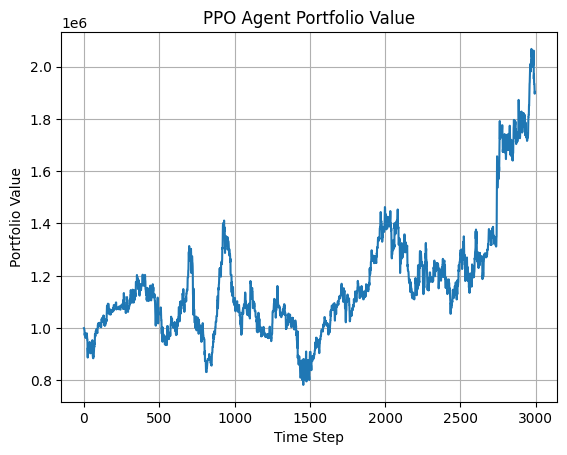

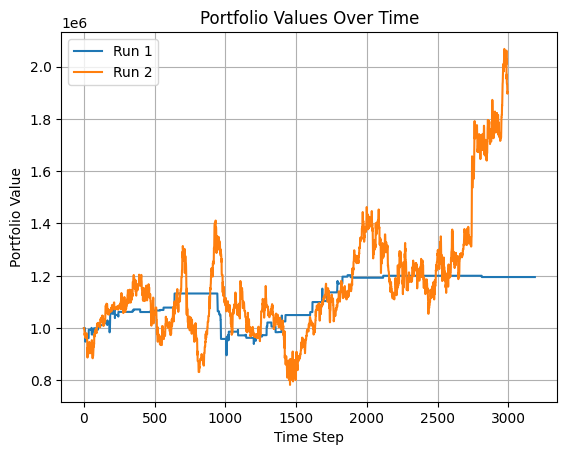

In [6]:
class PPOAgent:
    def __init__(self, state_dim, action_dim, gamma=0.99, clip=0.2, lr=1e-4, hidden_dim=64, n_hidden_layers=2):
        self.gamma = gamma
        self.clip = clip
        
        def make_mlp(input_dim, output_dim, hidden_dim, n_layers):
            layers = []
            in_dim = input_dim
            for _ in range(n_layers):
                layers.append(nn.Linear(in_dim, hidden_dim))
                layers.append(nn.ReLU())
                in_dim = hidden_dim
            layers.append(nn.Linear(hidden_dim, output_dim))
            return nn.Sequential(*layers)
        
        self.actor = nn.Sequential(
            *make_mlp(state_dim, action_dim, hidden_dim, n_hidden_layers),
            nn.Softmax(dim=-1)
        )
        
        self.critic = make_mlp(state_dim, 1, hidden_dim, n_hidden_layers)
        
        self.optimizer_actor = optim.Adam(self.actor.parameters(), lr=lr)
        self.optimizer_critic = optim.Adam(self.critic.parameters(), lr=lr)

    def select_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0)
        probs = self.actor(state)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)

    def compute_returns(self, rewards, dones, next_value):
        returns = []
        R = next_value
        for r, d in zip(reversed(rewards), reversed(dones)):
            R = r + self.gamma * R * (1 - d)
            returns.insert(0, R)
        return returns

    def update(self, trajectories):
        states, actions, log_probs_old, rewards, next_states, dones = zip(*trajectories)

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions)
        old_log_probs = torch.stack(log_probs_old).detach()
        dones = torch.FloatTensor(dones)
        next_states = torch.FloatTensor(next_states)

        with torch.no_grad():
            next_value = self.critic(next_states[-1]).item()
            returns = self.compute_returns(rewards, dones, next_value)
            returns = torch.FloatTensor(returns)
            advantages = returns - self.critic(states).squeeze()

        for _ in range(4):  # multiple epochs
            probs = self.actor(states)
            dist = torch.distributions.Categorical(probs)
            log_probs = dist.log_prob(actions)

            ratio = (log_probs - old_log_probs).exp()
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = nn.MSELoss()(self.critic(states).squeeze(), returns)

            self.optimizer_actor.zero_grad()
            actor_loss.backward()
            self.optimizer_actor.step()

            self.optimizer_critic.zero_grad()
            critic_loss.backward()
            self.optimizer_critic.step()

def plot_ppo_performance(agent, env):
    state = env.reset()
    portfolio_values = []

    done = False
    while not done:
        action, _ = agent.select_action(state)
        state, reward, done, _ = env.step(action)
        portfolio_values.append(env.get_value())  # Assuming your env has get_value()

    plt.plot(portfolio_values)
    plt.title("PPO Agent Portfolio Value")
    plt.xlabel("Time Step")
    plt.ylabel("Portfolio Value")
    plt.grid(True)
    plt.show()

    return portfolio_values

def optimize_ppo(trial, prices):
    gamma = trial.suggest_float('gamma', 0.85, 0.999)
    clip = trial.suggest_float('clip', 0.1, 0.3)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    hidden_dim = trial.suggest_int('hidden_dim', 32, 128)
    n_hidden_layers = trial.suggest_int('n_hidden_layers', 1, 2)

    env = TradingEnv(prices)
    agent = PPOAgent(state_dim=env.window_size, action_dim=3, gamma=gamma, clip=clip, 
                     lr=lr, hidden_dim=hidden_dim, n_hidden_layers=n_hidden_layers)

    rewards_per_episode = []

    for ep in range(consts.EPISODES):
        state = env.reset()
        done = False
        total_reward = 0
        trajectories = []

        while not done:
            action, log_prob = agent.select_action(state)
            next_state, reward, done, _ = env.step(action)
            trajectories.append((state, action, log_prob, reward, next_state, done))
            state = next_state
            total_reward += reward

        agent.update(trajectories)
        rewards_per_episode.append(total_reward)

    return np.mean(rewards_per_episode[-3:])

def plot_ppo_res():
    portfolio_vals_arr = []
    for df in stock_dfs[:consts.RL_LIMIT]:
        prices = df['Close'].values
        env = TradingEnv(prices)
        study = optuna.create_study(direction='maximize')
        study.optimize(lambda trial: optimize_ppo(trial, prices), n_trials=10)

        best_params = study.best_trial.params

        try:
            fig = vis.plot_optimization_history(study)
            fig.show()

            fig2 = vis.plot_param_importances(study)
            fig2.show()
        except Exception:
            # since the number of trials and episodes are relatively small, optuna sometimes returns an error
            print("Error during plotting")

        print("Best PPO params:", study.best_trial.params)

        agent = PPOAgent(state_dim=env.window_size, action_dim=3,
                        gamma=best_params['gamma'], clip=best_params['clip'],
                        lr=best_params['lr'], hidden_dim=best_params['hidden_dim'],
                        n_hidden_layers=best_params['n_hidden_layers'])

        portfolio_values = plot_ppo_performance(agent, env)
        portfolio_vals_arr.append(portfolio_values)

        for i, portfolio_values in enumerate(portfolio_vals_arr):
            plt.plot(portfolio_values, label=f'Run {i+1}')

        plt.title('Portfolio Values Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Portfolio Value')
        plt.legend()
        plt.grid(True)
        plt.show() 

plot_ppo_res()